In [1]:
import numpy as np
import matplotlib.pyplot as plt

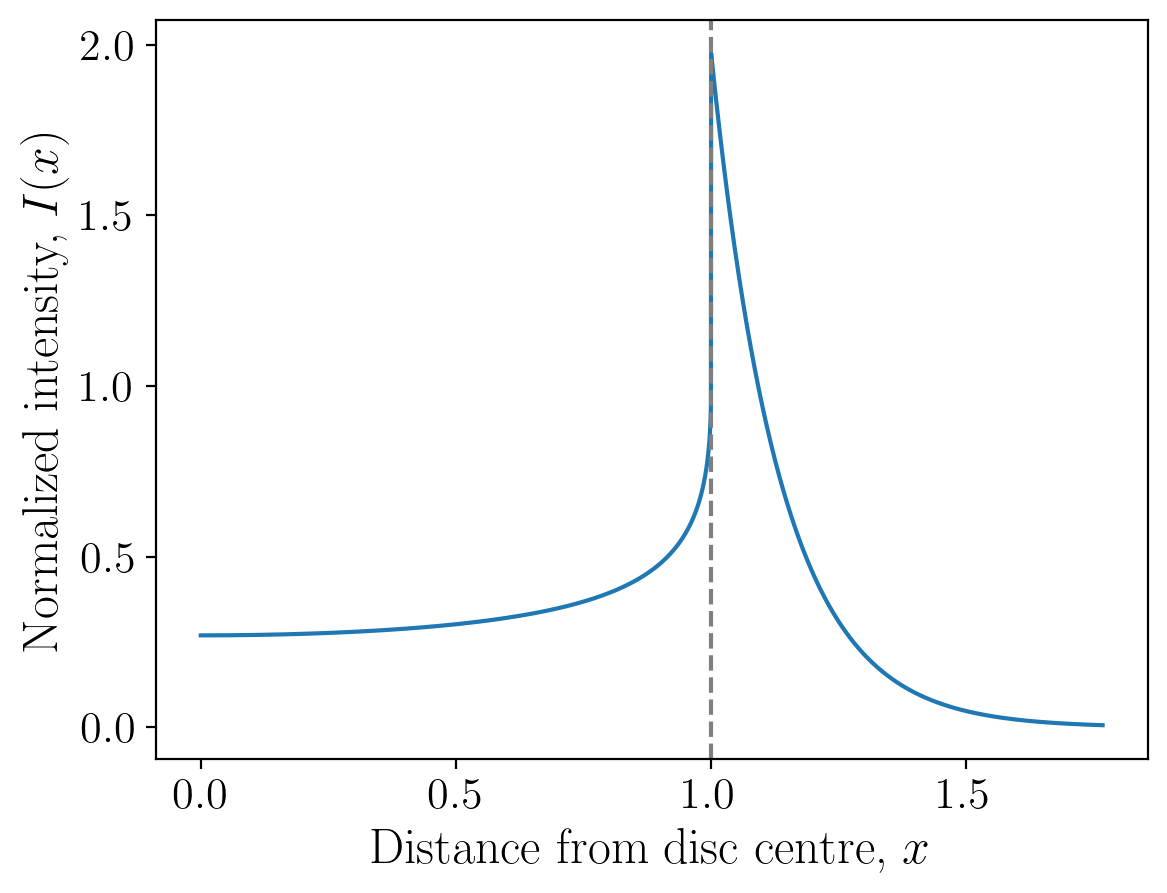

In [2]:
data = np.loadtxt("normalized_intensity_profile_hd189.txt", comments='#')
x_array = data[:, 0]
Intensity = data[:, 1]

plt.plot(x_array, Intensity)
plt.axvline(x=1, color='C7', ls='--')

plt.xlabel('Distance from disc centre, $x$',fontsize=18)
plt.ylabel('Normalized intensity, $I(x)$',fontsize=18)
plt.tick_params(labelsize=16)

In [ ]:
def overlapping_area(d, x, r):
    """
    Area of overlap between two circles of radii x (star annulus inner edge)
    and r (planet), whose centres are separated by distance d.
    """
    if d >= x + r:
        return 0.0
    if d <= abs(x - r):
        return np.pi * min(x, r) ** 2
    arg1 = (d*d + x*x - r*r) / (2.0 * d * x)
    arg2 = (d*d + r*r - x*x) / (2.0 * d * r)
    arg3 = (-d + x + r) * (d + x - r) * (d - x + r) * (d + x + r)
    arg3 = max(arg3, 0.0)   # guard against tiny negatives from floating point
    return (x*x * np.arccos(np.clip(arg1, -1, 1))
            + r*r * np.arccos(np.clip(arg2, -1, 1))
            - 0.5 * np.sqrt(arg3))


def obscuration_fraction(Intensity, x_array, rp, d):

    x_arr = x_array
    I_arr = Intensity

    numerator   = 0.0   # intensity-weighted blocked area
    denominator = 0.0   # intensity-weighted total stellar area (= total flux)

    for i in range(len(x_arr) - 1):
        x1 = x_arr[i]
        x2 = x_arr[i + 1]
        I  = 0.5 * (I_arr[i] + I_arr[i + 1])   # average intensity over annulus

        # Change in planet-overlap area as the annulus outer edge moves from x1 to x2
        blocked_in_annulus = overlapping_area(d, x2, rp) - overlapping_area(d, x1, rp)

        full_annulus = np.pi * (x2**2 - x1**2)

        numerator   += I * blocked_in_annulus
        denominator += I * full_annulus

    frac_percent = 100.0 * numerator / denominator
    return frac_percent


Planet radius  (Rp/Rs) : 0.145
Impact parameter (d/Rs): 1
Geometric (Rp/Rs)^2    : 2.1025%
Obscuration fraction   : 2.0087%


In [4]:
RpRs = 0.145   # Rp/Rs
D  = 1     # d/Rs

data = np.loadtxt("normalized_intensity_profile_hd189.txt", comments='#')
x_array = data[:, 0]
Intensity = data[:, 1]

frac = obscuration_fraction(Intensity, x_array, RpRs, D)

print(f"Planet radius  (Rp/Rs) : {RpRs}")
print(f"Impact parameter (d/Rs): {D}")
print(f"Geometric (Rp/Rs)^2    : {100.0 * RpRs**2:.4f}%")
print(f"Obscuration fraction   : {frac:.4f}%")

Planet radius  (Rp/Rs) : 0.145
Impact parameter (d/Rs): 1
Geometric (Rp/Rs)^2    : 2.1025%
Obscuration fraction   : 2.0087%
